# PINCODE CLUSTERING ANALYSIS

### K-Means from scratch

Implementing K-Means clustering from scratch on Delhi pincode geographic data.

### K-Means Theory:
- Given data matrix X $\in$ R (samples x features) and chosen k
- We want centroids centr_1,...,centr_k such that $\sum_i |x_i - \text{centr}_{c(i)}|^2$ is minimized
- This is a non-convex optimization -> solved by alternating minimization (coordinate descent)

- Algorithm 
    - Initialization -> randomly choose k data points as initial centroids
    - Assignment step -> assign each point to the nearest centroid (argmin Euclidean distance)
    - Update step -> recompute each centroid as the mean of assigned points
    - Repeat until centroids converge or max iterations reached

- Limitations:
    - Sensitive to initialisation and scaling of features
    - Fails on elongated, non-convex clusters
    - Rotations and transformations can change results
  
### Implementation choices:
- K-means++ initialisation
- Normalised coords before clustering
- Outlier removals using real geographic data
- Choosing K via elbow, silhouette nd data analysis

### 1. LIBRARIES

In [119]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

### 2. DATA LOADING AND PREPROCESSING

**Steps performed:**
1. View dataset properties (columns, datatypes etc)
2. Filter for `StateName == "DELHI"`
3. Fill in missing values with real data
4. Remove duplicates if any
5. Check other stats like unique district count,office,deliveries etc to see if any irregularity present
6. Keep datapoints which actually lie inside Delhi according to actual ranges and visualise with state boundary `(lat: 28.4–29.0, lon: 76.8–77.3)`
7. Extract the columns to be used for clustering and normalise them with `minmax`

In [120]:
# Loading dataset
# low_memory set False to avoid datatype mixing
df = pd.read_csv("clustering_data.csv",low_memory=False)

# Viewing dataset properties
# df.info()
# df.head()
# df.describe()

# Delhi data extraction
delhi = df[df["StateName"] == "DELHI"].copy()
init_points = delhi.shape[0]   # Initially 564 entries


# Null values removal
print(f"\n Count entries with null values : {delhi.isnull().sum()}")
# Entries with null values
delhi[delhi.isnull().any(axis=1)]
# Fill in actual values of missing Lat and Longitudes
delhi.loc[delhi["Pincode"] == 110074, ["Latitude", "Longitude"]] = [28.4696, 77.1496]
# Confirm no null values left
print(f"\n Null entries count : {delhi.isnull().sum().sum()}")


# Duplicates removal
delhi.drop_duplicates(inplace=True)


 Count entries with null values : CircleName      0
RegionName      0
DivisionName    0
OfficeName      0
Pincode         0
OfficeType      0
Delivery        0
District        0
StateName       0
Latitude        1
Longitude       1
dtype: int64

 Null entries count : 0


In [121]:
# Convert coords to float
delhi['Latitude']  = pd.to_numeric(delhi['Latitude'],  errors='coerce')
delhi['Longitude'] = pd.to_numeric(delhi['Longitude'], errors='coerce')

# Other stats
# print("\nUnique Districts")
# print(delhi['District'].value_counts())

print("\nCoordinate Range")
print(f"Latitude  : {delhi['Latitude'].min()}  to  {delhi['Latitude'].max()}")
print(f"Longitude : {delhi['Longitude'].min()}  to  {delhi['Longitude'].max()}")

# print("\nOffice Types")
# print(delhi['OfficeType'].value_counts())

# print("\nDelivery Status")
# print(delhi['Delivery'].value_counts())


Coordinate Range
Latitude  : 17.413655  to  77.319318
Longitude : 25.59  to  90.412518


---
- Actual Delhi coordinate range is around
    - Latitudes ~ (28.4,29.0)
    - Longitude ~ (76.8,77.3)
  
So there are some outliers in the dataset which we need to remove  <br>
The code below uses geopandas to plot the geojson of delhi and scatter the given  points over it


Number of elements outside boundary : 70


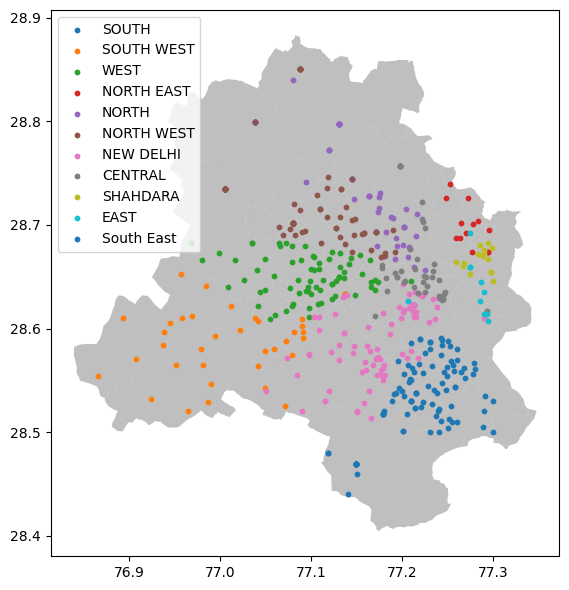

In [122]:
import geopandas as gpd

delhi = delhi[(delhi["Latitude"].between(28.4,29.0)) & (delhi["Longitude"].between(76.8,77.3))]
print(f"Number of elements outside boundary : {init_points - delhi.shape[0]}")
# https://gist.github.com/planemad/4ed2aafb493f3af53e554b9384ef07c7?short_path=3b0e81a#file-delhi-ac-geojson
gdf = gpd.read_file("Delhi_Boundary.geojson")
fig, ax = plt.subplots(figsize=(6,6))
gdf.plot(ax=ax,color="gray",alpha=0.5)
for district in delhi['District'].unique():
    mask = delhi['District']==district
    ax.scatter(delhi["Longitude"][mask], delhi["Latitude"][mask], s=10,alpha=1,label=f"{district}")
ax.legend()
plt.tight_layout()
plt.show()


In [123]:
# Now we have all datapoints inside Delhi, we can normalise it to use clustering on it
# minmax normalisation
X = delhi[["Latitude","Longitude"]].values
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_norm = (X - X_min) / (X_max - X_min)
def denorm(z):
    return z * (X_max-X_min) + X_min
print(f"\nNormalised range (Latitude,Longitude): {X_norm.min(axis=0)} to {X_norm.max(axis=0)}")


Normalised range (Latitude,Longitude): [0. 0.] to [1. 1.]


### 3. PROCESSED DATA VISUALISATION

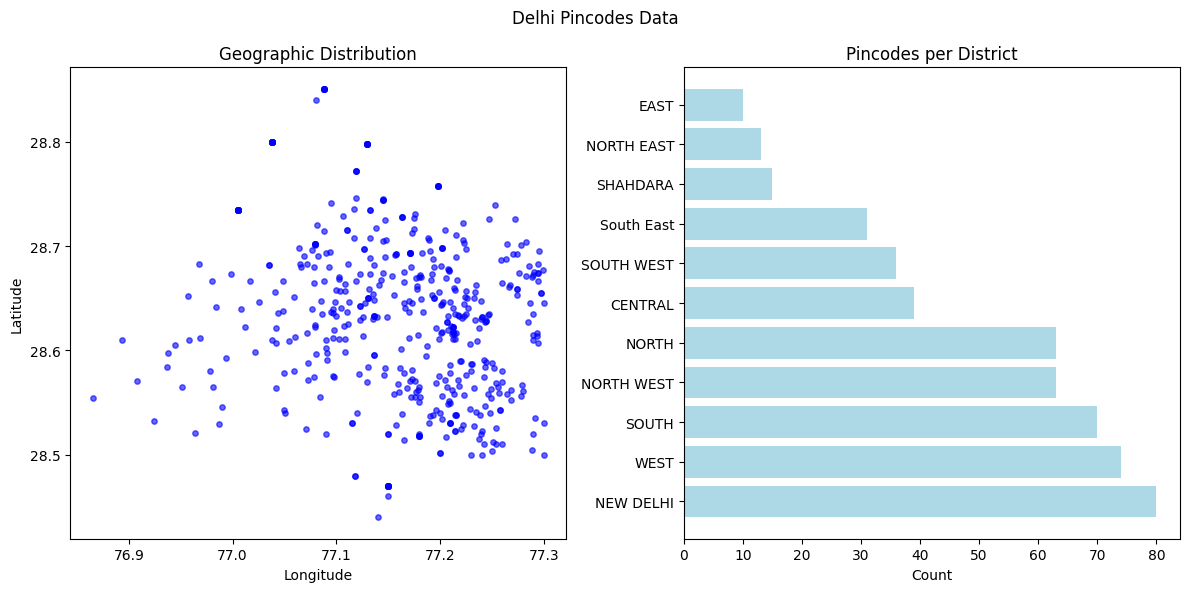

In [124]:
fig,ax = plt.subplots(1,2,figsize=(12,6))
fig.suptitle('Delhi Pincodes Data')

ax[0].scatter(delhi['Longitude'], delhi['Latitude'], s=15, alpha=0.6, c='blue')
ax[0].set_title('Geographic Distribution')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')

# .value_counts() returns unique values and their counts
dist_counts = delhi['District'].value_counts()
# vertical bars were making text overlapped
ax[1].barh(dist_counts.index, dist_counts.values, color='lightblue')
ax[1].set_title('Pincodes per District')
ax[1].set_xlabel('Count')


plt.tight_layout()
plt.show()



In [125]:
delhi.to_csv("delhi.csv",index=False)

### 4. Algorithm Implementation

#### 4.1 Helper Functions

In [126]:
# Distance / similarity functions
def euclidean(a,b):
    return np.sqrt(np.sum((a-b)**2))

#### 4.2 K-Means

- K-Means++ Initialisation: instead of randomly init of centroids, each succesive centroid is chosen with probability proportional to its distance from the nearest existing centroid. Implemented as:
    1. Pick 1st centroid randomly from data points `X[rng.integers(n_samples)]`
    2. For remaining `k-1` centroids calculate squared euclidean distance from every point to nearest centroid
    3. Create a probability distribution where $P(x) \propto {D(x)^2}_{nearest-centr}$
    4. Select next centroid based on these weights, so distant points have higher chance of being picked
- Convergence visualisation using sum of sqaures of distances from centroid within each cluster

In [127]:
def kmeans(X,k,max_iter=100,tol=1e-4):

    n_samples,_ = X.shape
    rng = np.random.default_rng(seed=42)
    
    # K-Means++ initialisation
    # pick random first centroid 
    centroids = [X[rng.integers(n_samples)]]
    
    # select remaining k-1 centroids using distance weighted probability
    for _ in range(k-1):

        #  follow the algorithm written in markdown above
        dists = np.array([min(euclidean(x,c)**2 for c in centroids) for x in X])
        prob = dists/dists.sum()

        centroids.append(X[rng.choice(len(X),p=prob)])
    centroids = np.array(centroids)

    history = [centroids.copy()]
    labels = np.zeros(len(X),dtype=int)
    objective_history = []

    for iter in range(max_iter):

        # assign labels 
        for i,x in enumerate(X):
            labels[i] = np.argmin([euclidean(x,c) for c in centroids])

        # track objective to analyse convergence behavior later
        objective= sum(euclidean(X[i],centroids[labels[i]])**2 for i in range(len(X)))
        objective_history.append(objective)

        # evalute new centroid as mean of current clusters
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        history.append(new_centroids)

        # stop if difference between succsessive centroids is less than tolerance
        if np.max(np.linalg.norm(new_centroids - centroids, axis=1)) < tol:
            print(f'K-Means Converged in {iter+1} iterations')
            break
        centroids = new_centroids

    return labels, centroids, objective_history, history

#### 4.3 K-Medoids

K-medoids is like k-means but uses real data points as centers instead of averages.
Because centers must be actual points, outliers (which are far from others) rarely get chosen, making it more robust to noise.
However, it is computationally much more expensive, so it scales poorly.

- Algorithmic difference : 
  - Replace medoid if a cluster member gives lower total intra-cluster distance
  - Use normal distance instead of squared distance as the objectivenow is $min \sum||x - c||$

In [128]:
def kmedoids(X,k,max_iter=100):
  
    # pick k random points as medoids 
    rng = np.random.default_rng(seed=42)
    medoid_idxs = rng.choice(len(X), k, replace=False)
    medoids = X[medoid_idxs]

    history = [medoids.copy()]
    labels = np.zeros(len(X),dtype=int)
    objective_history = []

    for iter in range(max_iter):

        # assign labels
        for i,x in enumerate(X):
            labels[i] = np.argmin([euclidean(x,X[m]) for m in medoid_idxs])

        # track objective value for convergence analysis
        objective = sum(euclidean(X[i],X[medoid_idxs[labels[i]]]) for i in range(len(X)))
        objective_history.append(objective)

        # for each cluster try each new member as a medoid and swap
        improved = False
        for j in range(k):
            cluster_pts = np.where(labels == j)[0]
            if len(cluster_pts) == 0:
                continue

            best_cost = sum(euclidean(X[i],X[medoid_idxs[j]]) for i in cluster_pts)
            best_med  = medoid_idxs[j]

            for candidate in cluster_pts:
                cost = sum(euclidean(X[i],X[candidate]) for i in cluster_pts)
                if cost < best_cost:
                    best_cost = cost
                    best_med  = candidate
                    improved  = True

            medoid_idxs[j] = best_med

        medoids = X[medoid_idxs]
        history.append(medoids)
        # if no swap occurs break
        if not improved:
            print(f'K-Medoids Converged in {iter+1} iterations')
            break

    return labels, medoids, medoid_idxs, objective_history

#### 4.4 Silhouette Score
$s(i) = \frac{b(i)-a(i)}{\max(a(i),b(i))}$
<br><br>
Where $a(i)$ = mean intra-cluster distance -- $a(i) = \frac{1}{|C_i -1|} \sum_{j \in C_i,j \ne i}{d(i,j)}$
<br><br>
$b(i)$ = mean dustance to nearest other cluster -- $b(i) = \min_{k \ne C_i} \frac{1}{C_k} \sum_{j \in C_k} {d(i,j)}$
<br><br>
The final silhouette score is the average over all points:
$S = \frac{1}{n} \sum_{i=1}^{n} s(i)$


In [129]:
def silhouette_score(X, labels):
    unique = np.unique(labels)
    scores = []
    for i, x in enumerate(X):
        ci = labels[i]
        same = X[labels == ci]
        a = np.mean([euclidean(x, p) for p in same if not np.array_equal(p,x)]) if len(same) > 1 else 0
        b_vals = [np.mean([euclidean(x, p) for p in X[labels == cj]]) for cj in unique if cj != ci]
        b = min(b_vals) if b_vals else 0
        m = max(a, b)
        scores.append((b - a) / m if m > 0 else 0)
    scores = np.array(scores)
    return scores.mean(), scores

## 5. Hyperparameter selection

In [130]:
K_RANGE = range(2, 12)
km_objectives, km_silhouettes = [], []

for k in K_RANGE:
    lkm, ckm, obj, _ = kmeans(X_norm, k)
    km_objectives.append(obj[-1])
    sil, _ = silhouette_score(X_norm, lkm)
    km_silhouettes.append(sil)

    print(f'K={k} | KMeans silhouette score ={sil:.4f}')

K-Means Converged in 7 iterations
K=2 | KMeans silhouette score =0.3876
K-Means Converged in 18 iterations
K=3 | KMeans silhouette score =0.3499
K-Means Converged in 19 iterations
K=4 | KMeans silhouette score =0.3890
K-Means Converged in 11 iterations
K=5 | KMeans silhouette score =0.3774
K-Means Converged in 30 iterations
K=6 | KMeans silhouette score =0.3487
K-Means Converged in 16 iterations
K=7 | KMeans silhouette score =0.3228
K-Means Converged in 16 iterations
K=8 | KMeans silhouette score =0.3590
K-Means Converged in 9 iterations
K=9 | KMeans silhouette score =0.3355
K-Means Converged in 26 iterations
K=10 | KMeans silhouette score =0.3674
K-Means Converged in 13 iterations
K=11 | KMeans silhouette score =0.3352


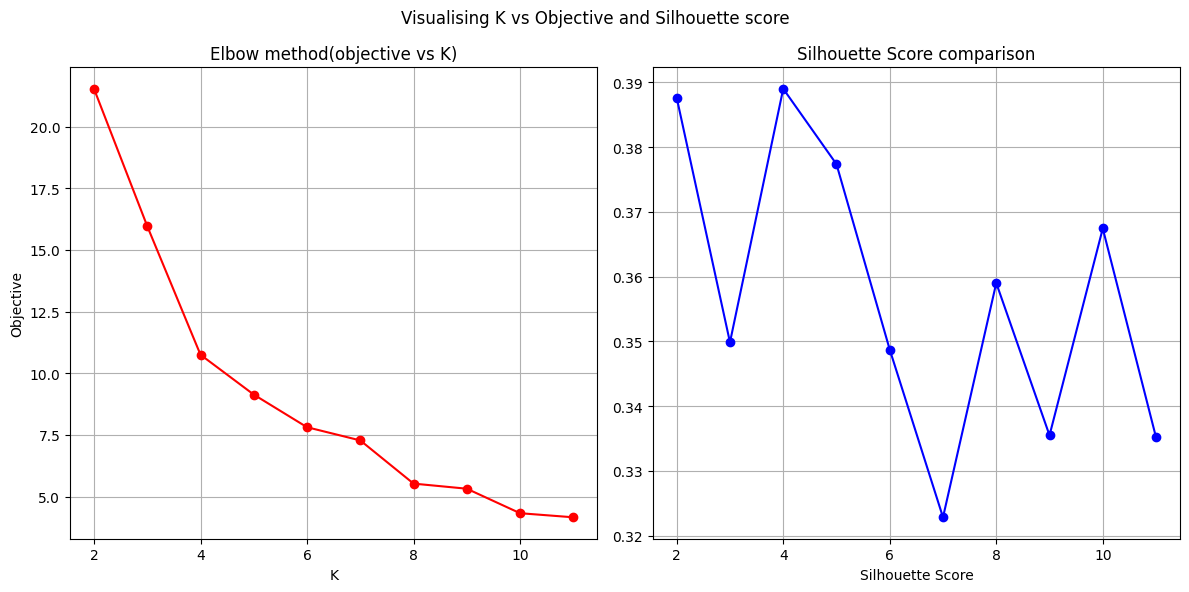

In [131]:
k_vals = list(K_RANGE)
fig,ax = plt.subplots(1,2,figsize=(12,6))
fig.suptitle("Visualising K vs Objective and Silhouette score")

ax[0].plot(k_vals,km_objectives,"o-",color="red")
ax[0].set_title("Elbow method(objective vs K)")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Objective")
ax[0].grid(True)

ax[1].plot(k_vals,km_silhouettes,"o-",color="blue")
ax[1].set_title("Silhouette Score comparison")
ax[1].set_xlabel("K")
ax[1].set_xlabel("Silhouette Score")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [132]:
print(*[f"{x:.4f}\n" for x in km_objectives])

21.5305
 15.9596
 10.7472
 9.1318
 7.8092
 7.2737
 5.5231
 5.3163
 4.3229
 4.1573



In unsupervised learning, selecting the number of clusters $K$ shouldnt be done fully automated with one or more metrics, because there is no ground truth to validate that against.
- Each metric and clustering algo will have its own assumptions which wont apply to each and every dataset 
- Like silhouette score measures how well each point fits into its own cluster compared to the nearest other and objective func measures compactness within cluster

K-means with these metrics which rely on compactness and nearness will favor coarse partitions (like K=2 here) which ignore substructure meaning
* This is a limitation of the algorithms assumptions, other methods like Spectral clustering or GMM can capture non-convex, complex nd overlapping structures

So choosing K requires taking into consideration both the metrics, understanding the given data and assumptions of the clustering model

In [133]:
# based on above metrics and more reasons given in inference section i chose K=4
K = 4
labels, centroids, obj_hist, km_history = kmeans(X_norm,K)
labels_med, medoids, medoid_idx, obj_hist_med = kmedoids(X_norm,K)

centroids = denorm(centroids)
medoids   = denorm(medoids)

# add the cluster assignments to initial dataset
delhi['km_cluster'] = labels
delhi['kmed_cluster'] = labels_med

# calculate the silhouette_score (avg + history)
sil, sil_pts  =silhouette_score(X_norm, labels)
sil_med, sil_med_pts =silhouette_score(X_norm, labels_med)

# number of scores in history = iterations
print(f'K-Means   silhouette: {sil}   | iterations: {len(obj_hist)}')
print(f'K-Medoids silhouette: {sil_med}   | iterations: {len(obj_hist_med)}')

# split the dataset according to labels and compute statistics 
stats = delhi.groupby('km_cluster').agg(Count=('Latitude','count'),Lat_mean=('Latitude','mean'),Lon_mean=('Longitude','mean'),Lat_std=('Latitude','std'),Lon_std=('Longitude','std'),Office=('OfficeType','count'))

# spread measures how far the points are scattered around its centre
stats['Spread'] = np.sqrt(stats['Lat_std']**2 + stats['Lon_std']**2)
print('\nK-Means Cluster Statistics:')
print(stats)

K-Means Converged in 19 iterations
K-Medoids Converged in 7 iterations
K-Means   silhouette: 0.389020157168437   | iterations: 19
K-Medoids silhouette: 0.3829819157246763   | iterations: 7

K-Means Cluster Statistics:
            Count   Lat_mean   Lon_mean   Lat_std   Lon_std  Office    Spread
km_cluster                                                                   
0             114  28.620898  77.064647  0.040963  0.062314     114  0.074572
1             156  28.658462  77.220471  0.031302  0.042702     156  0.052946
2              90  28.752115  77.094807  0.047434  0.054281      90  0.072086
3             134  28.540416  77.206244  0.034900  0.044279     134  0.056379


In [134]:
print(*[f"{x:.4f}\n" for x in km_silhouettes])

0.3876
 0.3499
 0.3890
 0.3774
 0.3487
 0.3228
 0.3590
 0.3355
 0.3674
 0.3352



## 6. Visualisations

#### 6.1 K-Means Cluster Map

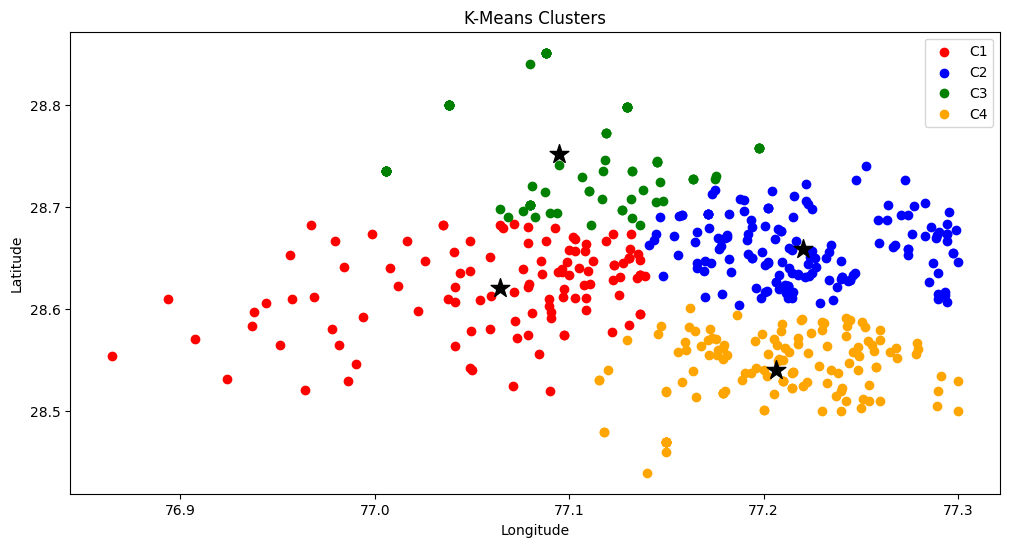

In [135]:
colors = ['red','blue','green','orange','purple','brown','pink','gray','black','cyan']
fig,ax = plt.subplots(figsize=(12,6))

for k in range(K):
    mask = (labels == k)
    ax.scatter(delhi['Longitude'][mask], delhi['Latitude'][mask],color=colors[k], label=f'C{k+1}')

ax.scatter(centroids[:,1], centroids[:,0], marker='*', s=200, color='black')

ax.set_title("K-Means Clusters")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()
plt.show()

#### 6.2 K-Medoids Cluster Map

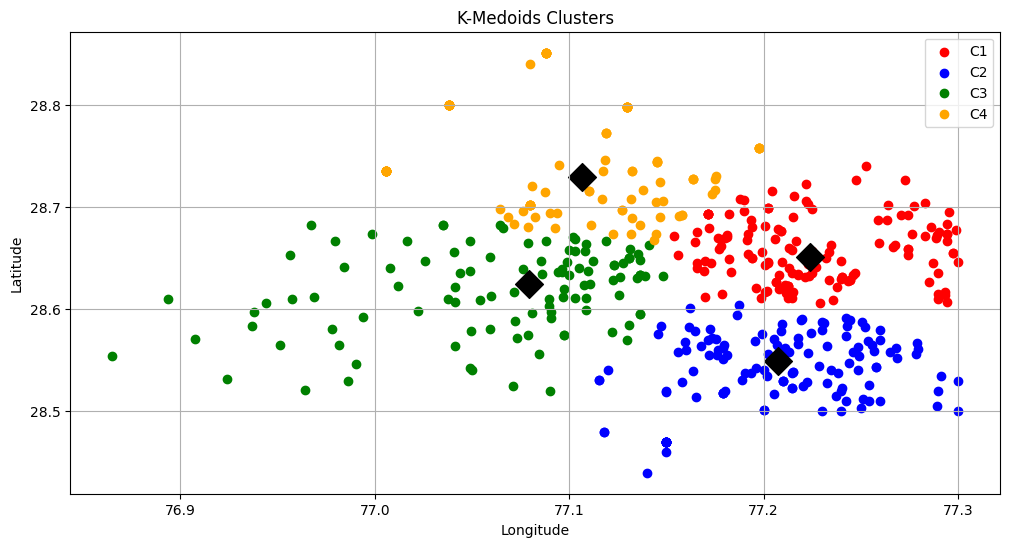

In [136]:
fig,ax = plt.subplots(figsize=(12,6))

for k in range(K):
    mask = (labels_med == k)
    ax.scatter(delhi['Longitude'][mask], delhi['Latitude'][mask],color=colors[k], label=f'C{k+1}')

ax.scatter(medoids[:,1], medoids[:,0], marker='D', s=200, color='black')
ax.set_title("K-Medoids Clusters")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
plt.legend()
plt.show()

#### 6.3 Side by side comparison vs divisions

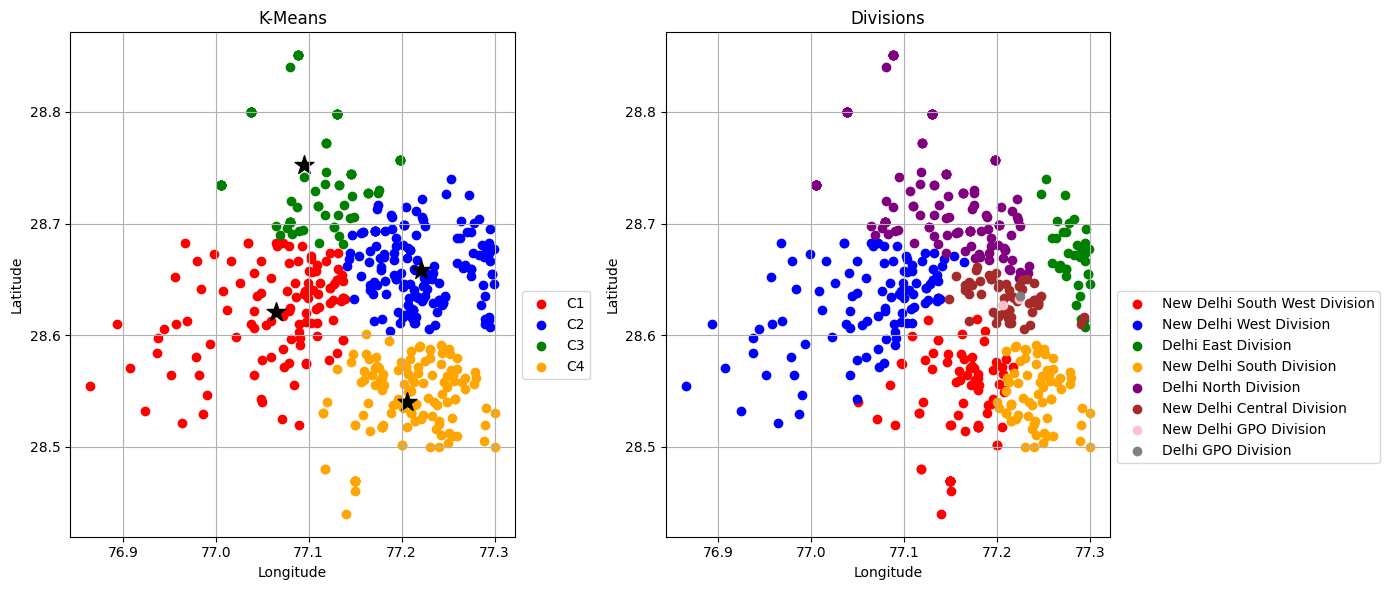

In [137]:
fig,ax = plt.subplots(1,2,figsize=(14,6))

for k in range(K):
    mask1 = labels==k
    ax[0].scatter(delhi['Longitude'][mask1], delhi['Latitude'][mask1],color=colors[k], label=f'C{k+1}')
for i, division in enumerate(delhi["DivisionName"].unique()):
    mask = (delhi["DivisionName"] == division)
    ax[1].scatter(delhi['Longitude'][mask], delhi['Latitude'][mask], color=colors[i % len(colors)], label=f'{division}')
ax[0].scatter(centroids[:,1], centroids[:,0], marker='*', s=200, color='black')

ax[0].set_title("K-Means")
ax[1].set_title("Divisions")

for a in ax:
    a.set_xlabel("Longitude")
    a.set_ylabel("Latitude")
    a.grid(True)
    # place the legned outside
    a.legend(bbox_to_anchor=(1,0.5))

plt.tight_layout()
plt.show()

#### 6.4 Convergence visualisation

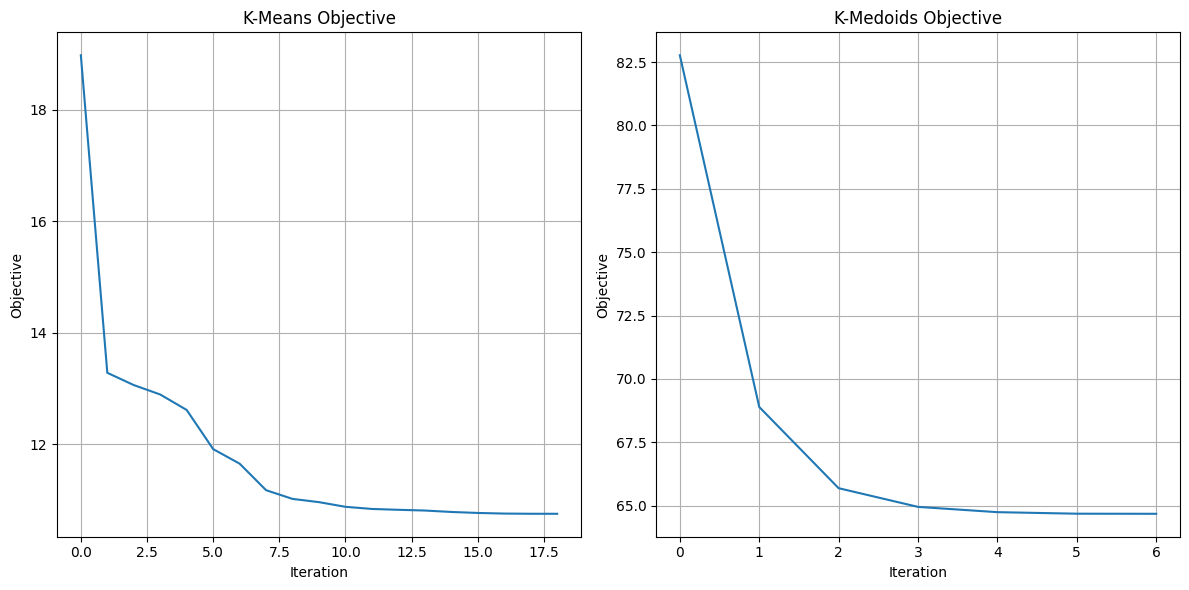

In [138]:
fig,ax = plt.subplots(1,2,figsize=(12,6))

ax[0].plot(range(len(obj_hist)), obj_hist)
ax[0].set_title("K-Means Objective")

ax[1].plot(range(len(obj_hist_med)), obj_hist_med)
ax[1].set_title("K-Medoids Objective")

for a in ax:
    a.set_xlabel("Iteration")
    a.set_ylabel("Objective")
    a.grid(True)

plt.tight_layout()
plt.show()

#### 6.5 Cluster sizes and spread graphs

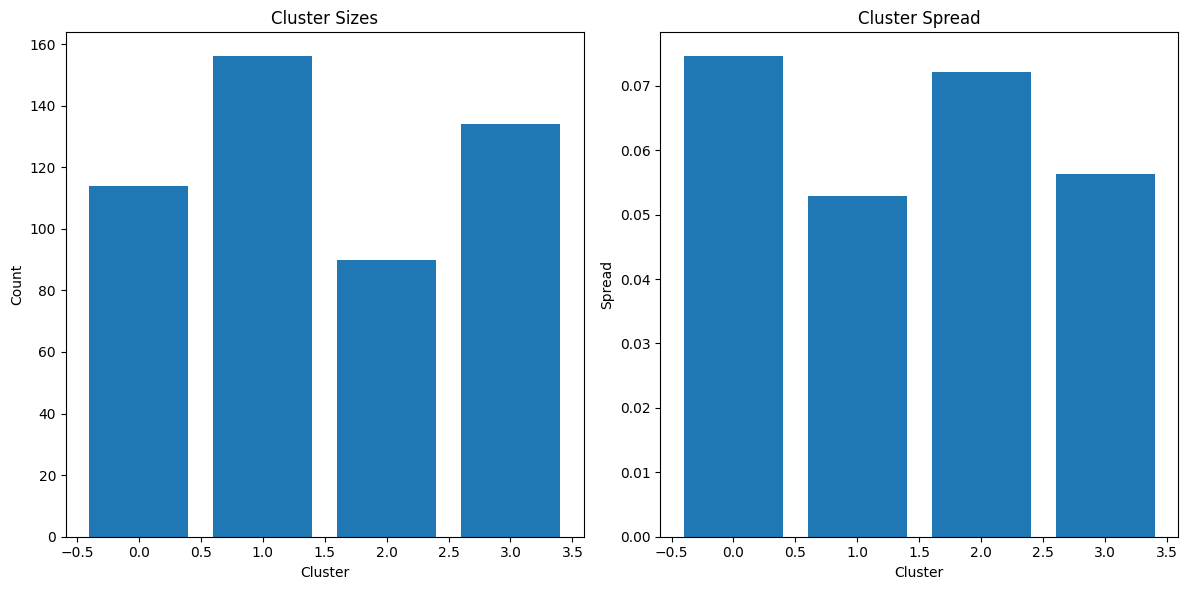

In [139]:
fig,ax = plt.subplots(1,2,figsize=(12,6))

# Cluster sizes
ax[0].bar(stats.index, stats['Count'])
ax[0].set_title("Cluster Sizes")
ax[0].set_xlabel("Cluster")
ax[0].set_ylabel("Count")


# Spread
ax[1].bar(stats.index, stats['Spread'])
ax[1].set_title("Cluster Spread")
ax[1].set_xlabel("Cluster")
ax[1].set_ylabel("Spread")


plt.tight_layout()
plt.show()

#### 6.6 Centroid movement

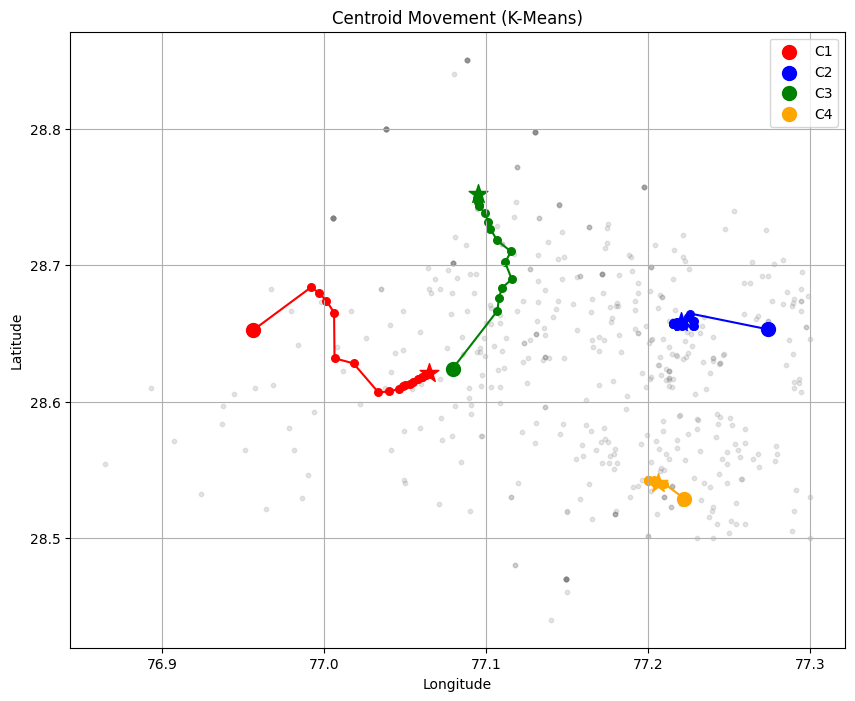

In [140]:
fig,ax = plt.subplots(figsize=(10,8))

ax.scatter(delhi['Longitude'], delhi['Latitude'], s=10, alpha=0.2, color='gray')

for k in range(K):
    path_lat = [denorm(km_history[t])[k,0] for t in range(len(km_history))]
    path_lon = [denorm(km_history[t])[k,1] for t in range(len(km_history))]

    ax.plot(path_lon, path_lat, color=colors[k])
    ax.scatter(path_lon, path_lat, color=colors[k], s=30)
    ax.scatter(path_lon[0], path_lat[0], marker='o', s=100, color=colors[k],label=f"C{k+1}")
    ax.scatter(path_lon[-1], path_lat[-1], marker='*', s=200, color=colors[k])

ax.set_title("Centroid Movement (K-Means)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
ax.grid(True)

plt.show()

K-Means Converged in 11 iterations


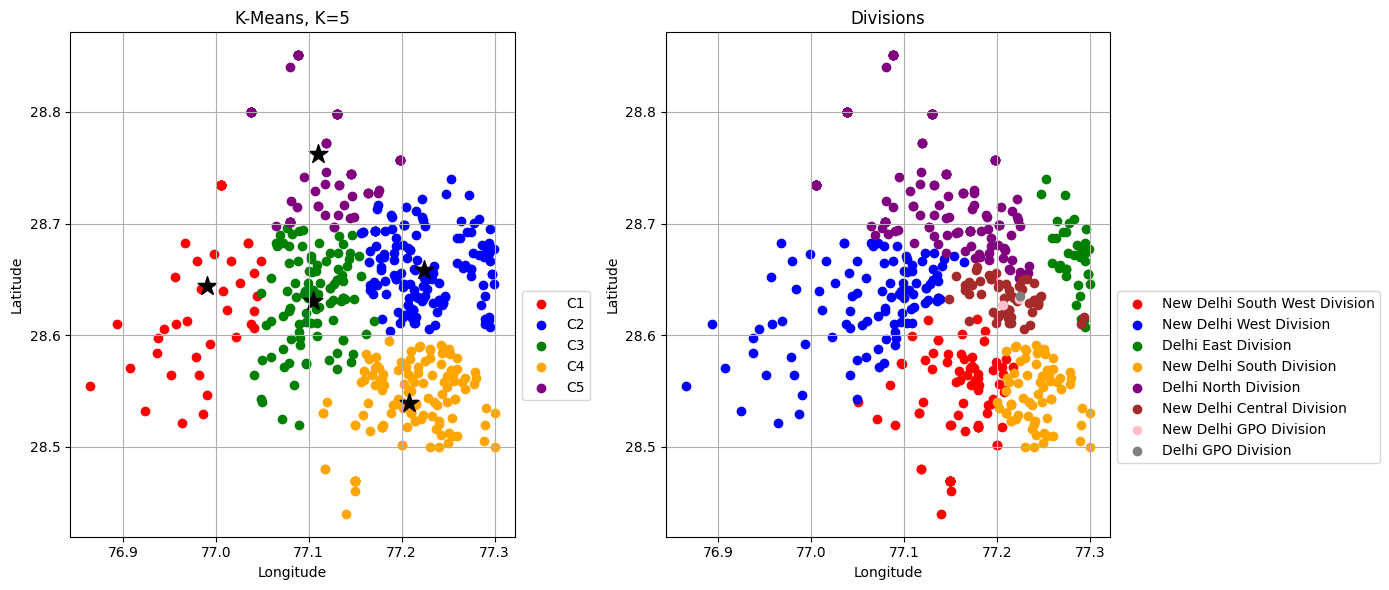

In [141]:
K_custom = 5
labels_custom, centroids_custom, obj_hist_custom, km_history_custom = kmeans(X_norm, K_custom)
centroids_custom = denorm(centroids_custom)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))


for k in range(K_custom):
    mask1 = labels_custom==k
    ax[0].scatter(delhi['Longitude'][mask1], delhi['Latitude'][mask1],color=colors[k], label=f'C{k+1}')
for i, division in enumerate(delhi["DivisionName"].unique()):
    mask = (delhi["DivisionName"] == division)
    ax[1].scatter(delhi['Longitude'][mask], delhi['Latitude'][mask], color=colors[i % len(colors)], label=f'{division}')
ax[0].scatter(centroids_custom[:,1], centroids_custom[:,0], marker='*', s=200, color='black')

ax[0].set_title(f"K-Means, K={K_custom}")
ax[1].set_title("Divisions")

for a in ax:
    a.set_xlabel("Longitude")
    a.set_ylabel("Latitude")
    a.grid(True)
    # place the legned outside
    a.legend(bbox_to_anchor=(1,0.5))

plt.tight_layout()
plt.show()

In [142]:
print(*[f"{x:.4f}\n" for x in km_silhouettes])

0.3876
 0.3499
 0.3890
 0.3774
 0.3487
 0.3228
 0.3590
 0.3355
 0.3674
 0.3352



## 7. Cluster level analysis

### 7.1 OfficeType

In [ ]:
# unstack to convert into 2D array and fill Nan's with 0's
office_breakdown = delhi.groupby(['km_cluster', 'OfficeType']).size().unstack(fill_value=0)
print("Office Type Breakdown per Cluster:")
print(office_breakdown)

Office Type Breakdown per Cluster:
OfficeType  BO  HO   PO
km_cluster             
0           38   2   74
1            4   6  146
2           48   0   42
3           30   3  101


### 7.2 Delivery

In [154]:
# calc the delivery% in each cluster as the ratio of delivery / total offices in each cluster|
delivery_breakdown = delhi.groupby(['km_cluster', 'Delivery']).size().unstack()
delivery_breakdown['Delivery%'] = (delivery_breakdown['Delivery'] / delivery_breakdown.sum(axis=1) * 100).round()
print("\nDelivery Breakdown per Cluster:")
print(delivery_breakdown)


Delivery Breakdown per Cluster:
Delivery    Delivery  Non Delivery  Delivery%
km_cluster                                   
0                 41            73       36.0
1                 27           129       17.0
2                 55            35       61.0
3                 30           104       22.0


### 7.3 Allignment of clusters against actual divisions
| Cluster | Rough region |
|---------|--------------|
|  0 | South + South-West |
| 1  | East + Central + North |
| 2  | North |
| 3  | Souht + South West |

This shows with K=4 we were able to perfectly separate almost all regions except the higly overlapping offices in the Central / North area

In [ ]:
print("\nRegion distribution per cluster:")
print(delhi.groupby(['km_cluster', 'RegionName']).size().unstack(fill_value=0))

print("\nDivision distribution per cluster:")
print(delhi.groupby(['km_cluster', 'DivisionName']).size())


Region distribution per cluster:
RegionName  DivReportingCircle
km_cluster                    
0                          114
1                          156
2                           90
3                          134

Division distribution per cluster:
km_cluster  DivisionName                 
0           New Delhi South West Division     13
            New Delhi West Division          101
1           Delhi East Division               38
            Delhi GPO Division                 1
            Delhi North Division              49
            New Delhi Central Division        60
            New Delhi GPO Division             2
            New Delhi South West Division      2
            New Delhi West Division            4
2           Delhi North Division              90
3           New Delhi South Division          69
            New Delhi South West Division     65
dtype: int64


### 7.4 K-Medoids Hub office predictions

In [158]:
# Actual post office at each K-Medoids hub
print("K-Medoids Hub Offices:")
for k, idx in enumerate(medoid_idx):
    row = delhi.iloc[idx]
    print(f"    C{k+1}: {row['OfficeName']}  ({row['Latitude']:.4f}N, {row['Longitude']:.4f}E)  [{row['OfficeType']}]")

K-Medoids Hub Offices:
    C1: Chawri Bazar SO  (28.6511N, 77.2242E)  [PO]
    C2: Hauz Khas SO  (28.5489N, 77.2073E)  [PO]
    C3: Janakpuri A 3 S.O  (28.6241N, 77.0794E)  [PO]
    C4: Rohini sec11 SO  (28.7288N, 77.1068E)  [PO]


### 7.5 Predictions

In [162]:
# Predicted cluster per pincode
predictions = delhi[['Pincode', 'OfficeName', 'District', 'Latitude', 'Longitude', 'km_cluster', 'kmed_cluster']].copy()
predictions.columns = ['Pincode', 'OfficeName', 'District', 'Latitude', 'Longitude', 'KMeans_Cluster', 'KMedoids_Cluster']
predictions = predictions.sort_values('KMeans_Cluster').reset_index(drop=True)
print("\nPredictions:")
print(predictions.to_string())


Predictions:
     Pincode                             OfficeName    District   Latitude  Longitude  KMeans_Cluster  KMedoids_Cluster
0     110041                             Neelwal BO        WEST  28.666378  76.979654               0                 2
1     110061                 Shahbad Mohammadpur BO   NEW DELHI  28.540000  77.050000               0                 2
2     110072                      Jharoda Kalan B.O  SOUTH WEST  28.652588  76.956454               0                 2
3     110043                          Jhatikara B.O  SOUTH WEST  28.520905  76.964011               0                 2
4     110010                           A F Palam SO   NEW DELHI  28.577833  77.122167               0                 2
5     110010                                 CVD SO   NEW DELHI  28.598889  77.108583               0                 2
6     110071                        Kangan Heri B.O  SOUTH WEST  28.546186  76.990187               0                 2
7     110078              